# Fitting: Spectral Line Analysis

This notebook demonstrates how to easily fit `TimeSeries` or `FrequencySeries` data using the `gwexpy.fitting` module.
The backend uses `iminuit`, enabling least-squares fitting with error consideration.


In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import matplotlib.pyplot as plt
import numpy as np

from gwexpy.frequencyseries import FrequencySeries
from gwexpy.plot import Plot
from gwexpy.timeseries import TimeSeries

plt.rcParams["figure.figsize"] = (10, 6)

## 1. Data Preparation

Here we create dummy data by adding noise to a Gaussian function.


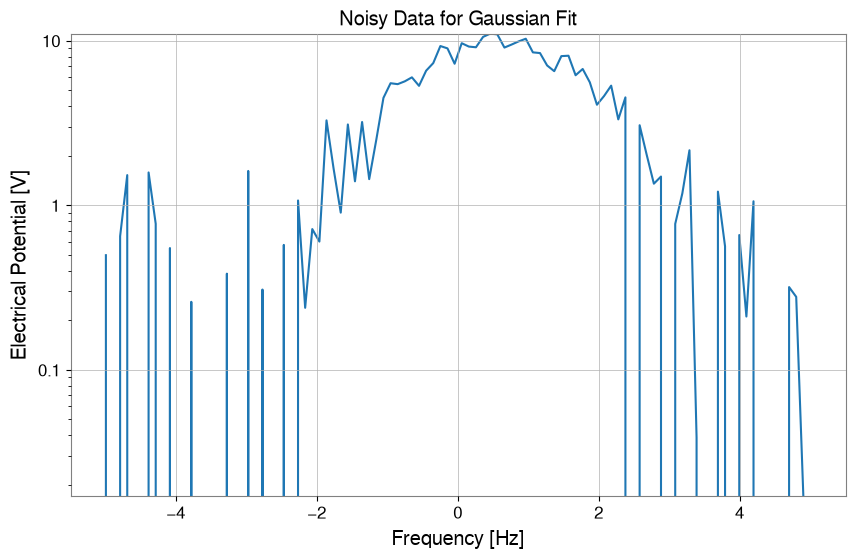

In [2]:
# Define model function (Gaussian)
def gaussian(x, a, mu, sigma):
    return a * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


# Generate dummy data on an explicit x-axis
np.random.seed(42)
x = np.linspace(-5, 5, 100)
true_params = {"a": 10, "mu": 0.5, "sigma": 1.2}
y_true = gaussian(x, **true_params)
y_noise = y_true + np.random.normal(0, 1.0, size=len(x))

# Use FrequencySeries so the fit axis matches the synthetic x values
ts = FrequencySeries(y_noise, frequencies=x, name="Noisy Gaussian", unit="V")
ts.plot(title="Noisy Data for Gaussian Fit");


## 2. Performing the Fit

Use the `ts.fit()` method to perform fitting.
Specify the model function and initial parameter values `p0` as arguments.

For narrow or localized peaks, constrain the center and width to physically meaningful ranges so the optimizer does not wander into a noise-only local minimum.


In [3]:
# Fitting
# Keep the initial center near the visible peak and bound (mu, sigma) to plausible values
gaussian_limits = {"mu": (-2.0, 2.0), "sigma": (0.2, 3.0)}
result = ts.fit(
    gaussian,
    sigma=0.8,
    p0={"a": 8.0, "mu": 0.0, "sigma": 1.0},
    limits=gaussian_limits,
)

# Display results
display(result)


## 3. Retrieving Results and Plotting

You can retrieve the best-fit parameters, errors, Chi2 values, etc. from the `FitResult` object.
Additionally, the `.plot()` method makes it easy to visualize the results.


Best Fit Parameters: {'a': 10.05306800420533, 'mu': 0.5500233455725477, 'sigma': 1.1710489113862708}
Errors: {'a': 0.21465080448975496, 'mu': 0.029072612212221238, 'sigma': 0.02846288237715988}
Chi2: 125.15392534185452
NDOF: 97


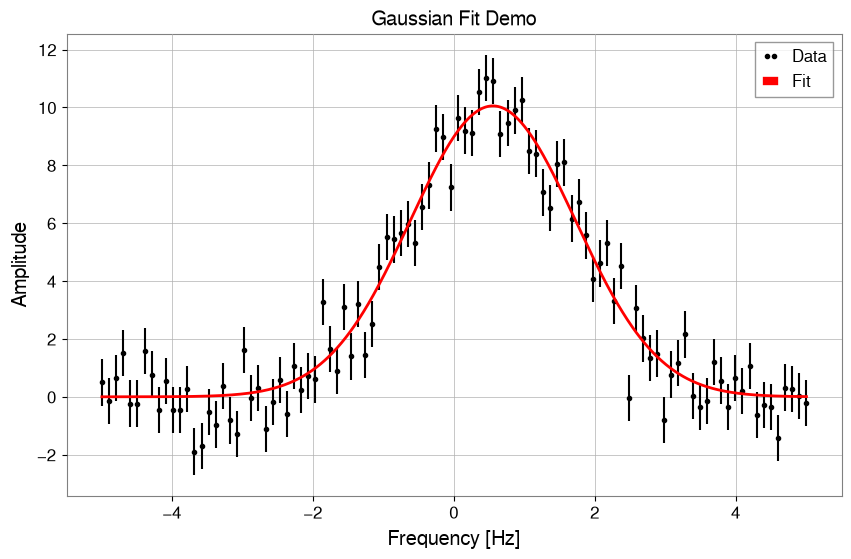

In [4]:
print("Best Fit Parameters:", result.params)
print("Errors:", result.errors)
print("Chi2:", result.chi2)
print("NDOF:", result.ndof)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
result.plot(ax=ax, color="red", linewidth=2)
ax.set_title("Gaussian Fit Demo")
# When using auto-gps, let GWpy handle xlabel (includes epoch)
ax.set_ylabel("Amplitude")
plt.show()

## 4. Specifying Models by String

Instead of defining a model function, you can specify a predefined model name as a string.
Currently supported models: `'gaus'`, `'exp'`, `'pol0'`, `'pol1'`, ... `'pol9'`, `'landau'`, etc.

Below is an example using `'gaus'`. Restrict the fit window to the actual visible peak so the predefined model is solving the same problem as the callable example above.


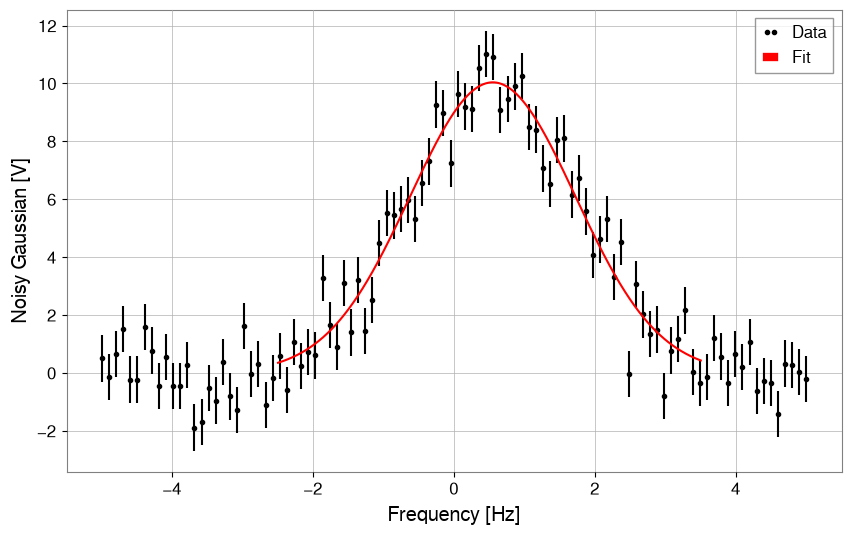

In [5]:
# Fit using string 'gaus'
# Note: Parameter names for predefined models are fixed (for Gaussian: A, mu, sigma)
result_str = ts.fit(
    "gaus",
    p0={"A": 8.0, "mu": 0.0, "sigma": 1.0},
    x_range=(-2.5, 3.5),
    sigma=0.8,
    limits={"mu": (-2.0, 2.0), "sigma": (0.2, 3.0)},
)

# Display results
display(result_str)
result_str.plot();


## 5. Complex Number Fitting (Transfer Functions)

You can also fit complex data such as transfer functions.
The cost function $\chi^2 = \sum (Re_{diff})^2 + \sum (Im_{diff})^2$ is minimized, fitting real and imaginary parts simultaneously.
The result plots automatically become Bode plots (magnitude and phase).


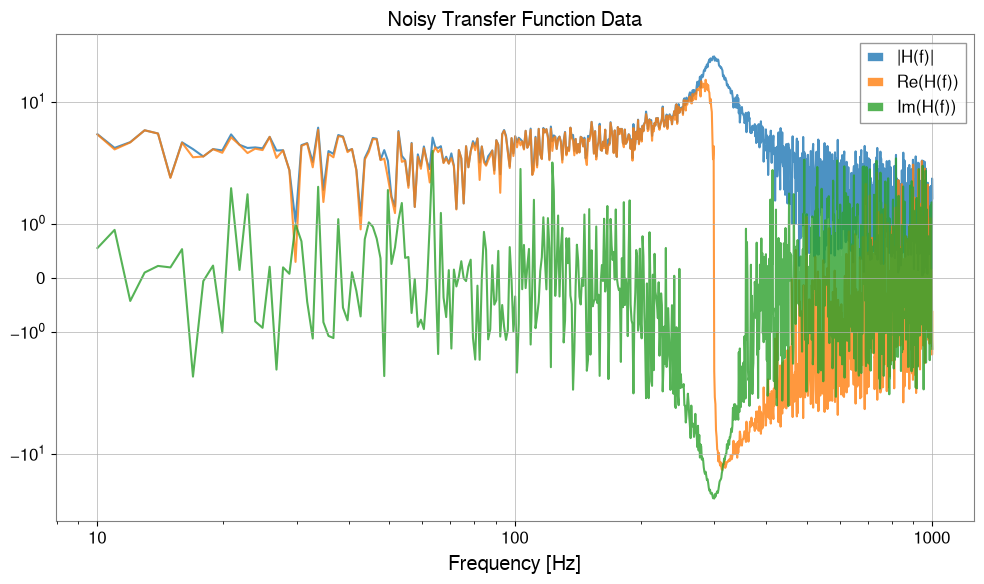

In [6]:
# 1. Define complex model (simple pole)
def pole_model(f, A, f0, Q):
    # H(f) = A / (1 + i * Q * (f/f0 - f0/f))
    # Low-pass filter like but simplified. Let's use standard mechanical transfer function:
    # H(f) = A / [ (f0^2 - f^2) + i * (f0 * f / Q) ]
    omega = 2 * np.pi * f
    omega0 = 2 * np.pi * f0
    return A / ((omega0**2 - omega**2) + 1j * (omega0 * omega / Q))


# 2. Generate data
f = np.linspace(10, 1000, 1000)
p_true = {"A": 1e7, "f0": 300, "Q": 10}
data_clean = pole_model(f, **p_true)

# Add noise (real and imaginary parts independent)
np.random.seed(0)
noise_re = np.random.normal(0, 5, len(f))
noise_im = np.random.normal(0, 5, len(f))
data_noisy = data_clean + 0.2 * noise_re + 0.2j * noise_im

# Create FrequencySeries
fs = FrequencySeries(data_noisy, frequencies=f, name="Transfer Function")
plot = Plot(fs.abs(), fs.real, fs.imag, xscale="log", yscale="symlog", alpha=0.8)
plt.legend(["|H(f)|", "Re(H(f))", "Im(H(f))"])
plt.title("Noisy Transfer Function Data")
plt.tight_layout()
plt.show()

Fit Start...


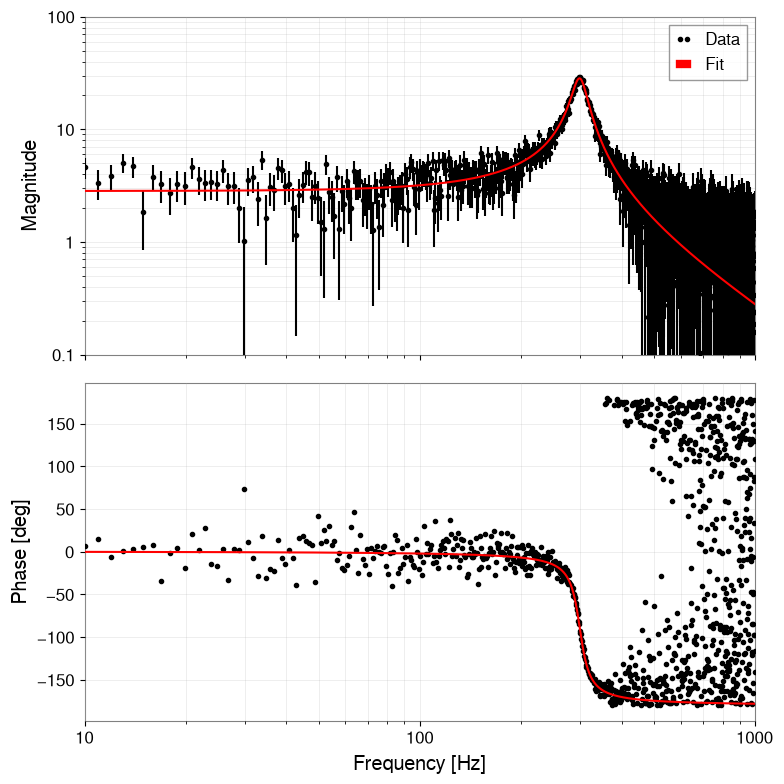

In [7]:
# 3. Fitting
print("Fit Start...")
# Use shifted initial values
result_complex = fs.fit(pole_model, sigma=1.0, p0={"A": 0.8e7, "f0": 320, "Q": 8})

# Display results
display(result_complex)

# 4. Plot (Bode plot)
# Automatically becomes amplitude and phase plots
result_complex.bode_plot()
plt.gcf().get_axes()[0].set_ylim(1e-1, 1e2)
plt.tight_layout()
plt.show()

## 6. MCMC Analysis (emcee)

Using the maximum likelihood estimate obtained from `iminuit` as the initial value, you can perform MCMC (Markov Chain Monte Carlo) analysis using `emcee`.

> **Note:** To use this feature, `emcee` and `corner` must be installed.


  0%|          | 0/1000 [00:00<?, ?it/s]

  3%|▎         | 28/1000 [00:00<00:03, 271.30it/s]

  6%|▌         | 56/1000 [00:00<00:03, 265.23it/s]

  8%|▊         | 84/1000 [00:00<00:03, 268.67it/s]

 11%|█         | 112/1000 [00:00<00:03, 270.75it/s]

...

 90%|████████▉ | 895/1000 [00:03<00:00, 273.99it/s]

 92%|█████████▏| 923/1000 [00:03<00:00, 274.19it/s]

 95%|█████████▌| 951/1000 [00:03<00:00, 274.45it/s]

 98%|█████████▊| 979/1000 [00:03<00:00, 274.21it/s]

100%|██████████| 1000/1000 [00:03<00:00, 272.14it/s]

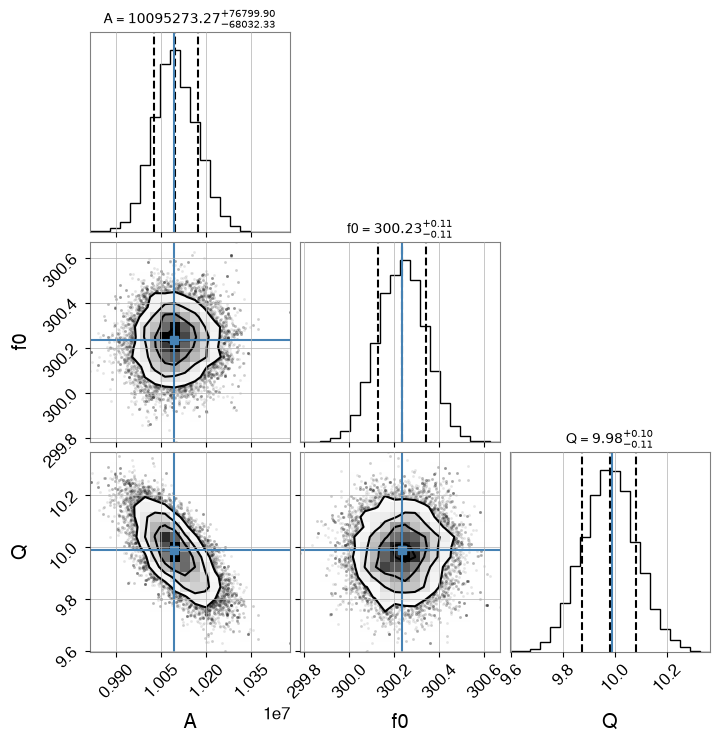

In [8]:
# Run MCMC
# n_walkers: number of walkers, n_steps: number of steps, burn_in: number of initial steps to discard
try:
    sampler = result_complex.run_mcmc(n_walkers=32, n_steps=1000, burn_in=200)

    # Create corner plot (visualize posterior distribution)
    # Display true values (or maximum likelihood estimates) with blue lines
    result_complex.plot_corner()

except ImportError as e:
    print(e)
except Exception as e:
    print(f"MCMC Error: {e}")

## Example Usage of New Common Models

These are usage examples of `power_law` and `damped_oscillation` added to `gwexpy.fitting.models`.


Power law alpha: -1.5073254489014472


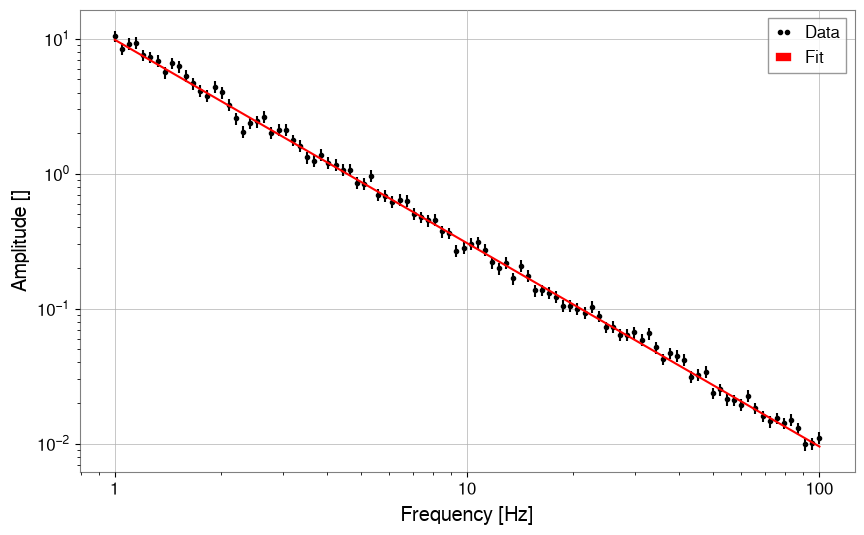

Damped oscillation frequency: 9.993425925552769


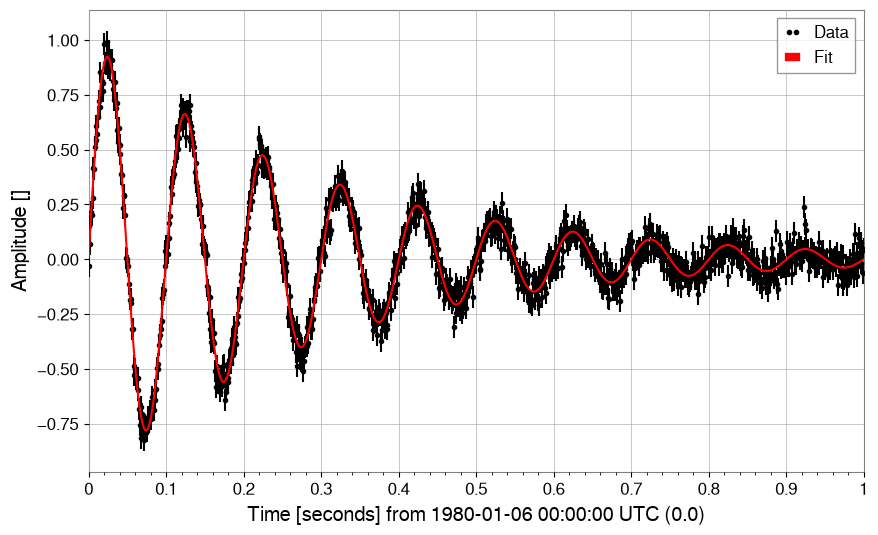

In [9]:
from gwexpy.fitting.models import damped_oscillation, power_law

# Power law
x = np.logspace(0, 2, 100)
y = power_law(x, A=10, alpha=-1.5) * (1 + 0.1 * np.random.normal(size=len(x)))
fs = FrequencySeries(y, frequencies=x)
res_pl = fs.fit("power_law", p0={"A": 5, "alpha": -1}, sigma=y * 0.1)
print("Power law alpha:", res_pl.params["alpha"])
display(res_pl)
res_pl.plot()
plt.xscale("log")
plt.yscale("log")
plt.show()
plt.close()

# Damped oscillation
t = np.linspace(0, 1, 1000)
y_osc = damped_oscillation(t, A=1, tau=0.3, f=10) + 0.05 * np.random.normal(size=len(t))
ts_osc = TimeSeries(y_osc, times=t)
res_osc = ts_osc.fit(
    "damped_oscillation", p0={"A": 0.5, "tau": 0.5, "f": 12}, sigma=0.05
)
print("Damped oscillation frequency:", res_osc.params["f"])
display(res_osc)
res_osc.plot();

## 7. Spectral Line Fitting: Lorentzian and Voigt Profiles

In gravitational-wave detector commissioning, narrowband resonances (mechanical
modes, violin modes, line injections) appear as sharp peaks in ASD spectra.  
Three profiles are commonly used:

| Model | When to use |
|-------|-------------|
| **Gaussian** | Doppler- or pressure-broadened lines; truly symmetric noise peaks |
| **Lorentzian** | Resonances with a single loss mechanism (Q-limited linewidth) |
| **Voigt** | Composite broadening (Gaussian instrument resolution + Lorentzian damping) |

All three are available in `gwexpy.fitting.models` and can be referenced by string.


### 7a. Lorentzian (HWHM parameterisation)

$$f(x) = \frac{A\,\gamma^2}{(x - x_0)^2 + \gamma^2}$$

- `A` : peak amplitude
- `x0`: centre frequency
- `gamma`: half-width at half-maximum (HWHM)


True  A=50.0, x0=110.0, gamma=0.8
Fit   A=50.50 ± 0.20
      x0=110.000 ± 0.003
      gamma=0.851 ± 0.005


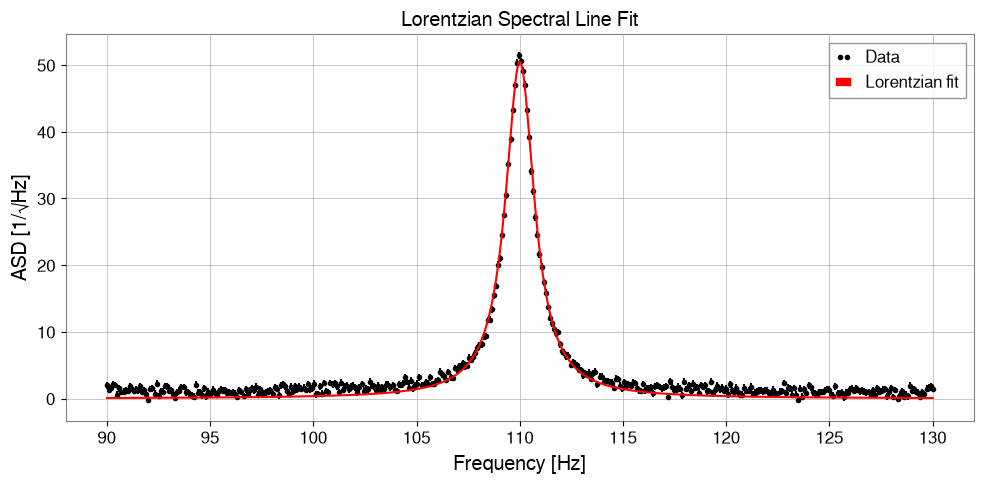

In [10]:
from gwexpy.fitting.models import lorentzian, voigt

# ── Synthetic ASD with a Lorentzian resonance peak ──────────────
np.random.seed(0)
freqs = np.linspace(90, 130, 400)   # Hz, around a 110 Hz mode
TRUE_A, TRUE_X0, TRUE_GAMMA = 50.0, 110.0, 0.8

y_lorenz = lorentzian(freqs, TRUE_A, TRUE_X0, TRUE_GAMMA)
noise = np.random.normal(0, 0.5, len(freqs))
y_data = y_lorenz + noise + 1.0   # +1 flat background

fs_lorenz = FrequencySeries(y_data, frequencies=freqs,
                           name='ASD with Lorentzian peak', unit='1/rtHz')

# ── Fit ─────────────────────────────────────────────────────────
res_lorenz = fs_lorenz.fit(
    'lorentzian',
    p0={'A': 30.0, 'x0': 112.0, 'gamma': 1.5},
    sigma=0.5,
)

print(f"True  A={TRUE_A}, x0={TRUE_X0}, gamma={TRUE_GAMMA}")
print(f"Fit   A={res_lorenz.params['A']:.2f} ± {res_lorenz.errors['A']:.2f}")
print(f"      x0={res_lorenz.params['x0']:.3f} ± {res_lorenz.errors['x0']:.3f}")
print(f"      gamma={res_lorenz.params['gamma']:.3f} ± {res_lorenz.errors['gamma']:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
res_lorenz.plot(ax=ax, label='Lorentzian fit')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('ASD [1/√Hz]')
ax.set_title('Lorentzian Spectral Line Fit')
ax.legend()
plt.tight_layout()
plt.show()

### 7b. Lorentzian Q-factor parameterisation

For resonators it is often more natural to express the linewidth via the
quality factor $Q = x_0 / (2\gamma)$:

$$f(x) = \frac{A\,\gamma^2}{(x - x_0)^2 + \gamma^2}, \quad \gamma = \frac{x_0}{2Q}$$

Use `'lorentzian_q'` to fit directly in terms of `(A, x0, Q)`.


True  Q = 68.75
Fit   Q = 64.63 ± 0.36
      x0 = 110.000 ± 0.003 Hz


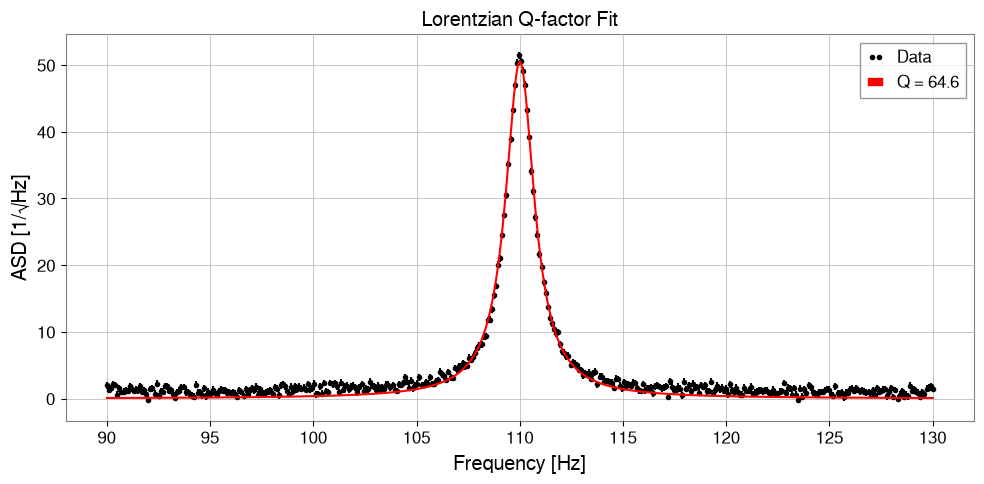

In [11]:
TRUE_Q = TRUE_X0 / (2 * TRUE_GAMMA)   # ~68.75

res_q = fs_lorenz.fit(
    'lorentzian_q',
    p0={'A': 30.0, 'x0': 112.0, 'Q': 50.0},
    sigma=0.5,
)

print(f"True  Q = {TRUE_Q:.2f}")
print(f"Fit   Q = {res_q.params['Q']:.2f} ± {res_q.errors['Q']:.2f}")
print(f"      x0 = {res_q.params['x0']:.3f} ± {res_q.errors['x0']:.3f} Hz")

fig, ax = plt.subplots(figsize=(10, 5))
res_q.plot(ax=ax, label=f"Q = {res_q.params['Q']:.1f}")
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('ASD [1/√Hz]')
ax.set_title('Lorentzian Q-factor Fit')
ax.legend()
plt.tight_layout()
plt.show()

### 7c. Voigt Profile

The Voigt profile is the convolution of a Gaussian (width $\sigma$) and a Lorentzian
(HWHM $\gamma$).  It is computed via the **Faddeeva function** for efficiency.

Use it when the line shows both instrument-resolution broadening (Gaussian) and
intrinsic damping (Lorentzian).


Lorentzian  chi2/ndof = 1278.6/397
Voigt       chi2/ndof = 766.8/396
Recovered sigma=0.415 (true 0.5), gamma=0.522 (true 0.4)


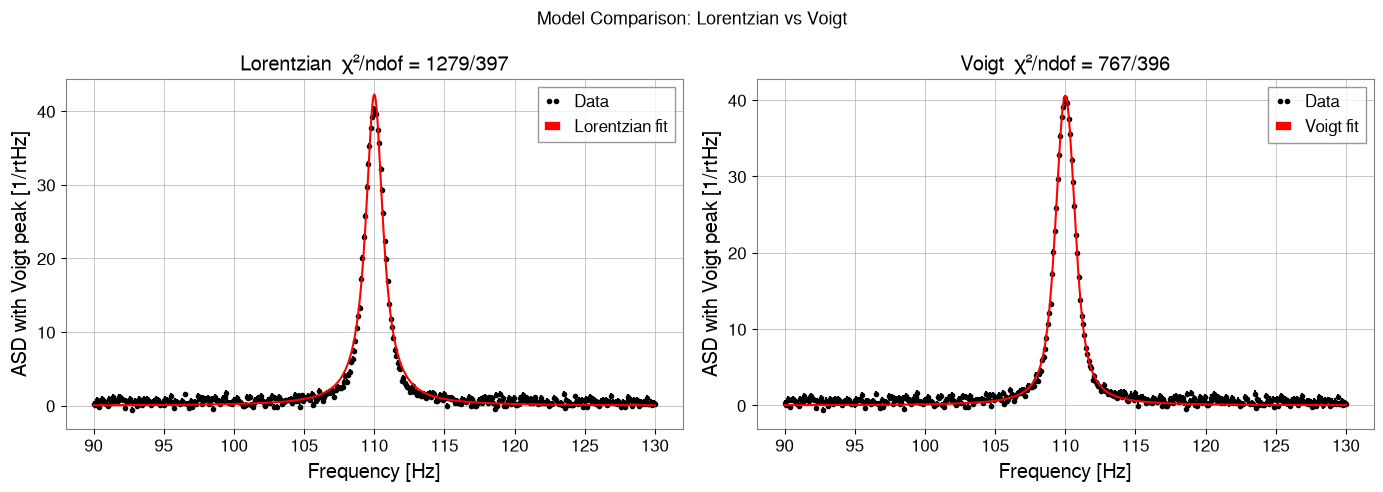

In [12]:
# ── Synthetic data with mixed broadening ─────────────────────────
TRUE_SIGMA, TRUE_GAMMA_V = 0.5, 0.4
y_voigt = voigt(freqs, A=40.0, x0=110.0, sigma=TRUE_SIGMA, gamma=TRUE_GAMMA_V)
y_data_v = y_voigt + np.random.normal(0, 0.4, len(freqs)) + 0.5

fs_voigt = FrequencySeries(y_data_v, frequencies=freqs,
                          name='ASD with Voigt peak', unit='1/rtHz')

# Fit Lorentzian (wrong model) for comparison
res_l = fs_voigt.fit('lorentzian', p0={'A': 30.0, 'x0': 111.0, 'gamma': 0.8},
                     sigma=0.4)

# Fit Voigt (correct model)
res_v = fs_voigt.fit('voigt',
                     p0={'A': 30.0, 'x0': 111.0, 'sigma': 0.6, 'gamma': 0.5},
                     sigma=0.4)

print(f"Lorentzian  chi2/ndof = {res_l.chi2:.1f}/{res_l.ndof}")
print(f"Voigt       chi2/ndof = {res_v.chi2:.1f}/{res_v.ndof}")
print(f"Recovered sigma={res_v.params['sigma']:.3f} (true {TRUE_SIGMA}),"
      f" gamma={res_v.params['gamma']:.3f} (true {TRUE_GAMMA_V})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
res_l.plot(ax=axes[0], label='Lorentzian fit')
axes[0].set_title(f"Lorentzian  χ²/ndof = {res_l.chi2:.0f}/{res_l.ndof}")
axes[0].set_xlabel('Frequency [Hz]')
axes[0].legend()

res_v.plot(ax=axes[1], label='Voigt fit')
axes[1].set_title(f"Voigt  χ²/ndof = {res_v.chi2:.0f}/{res_v.ndof}")
axes[1].set_xlabel('Frequency [Hz]')
axes[1].legend()

plt.suptitle('Model Comparison: Lorentzian vs Voigt', fontsize=13)
plt.tight_layout()
plt.show()